# 1 — Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# 2 — Đọc dữ liệu

In [2]:
orders = pd.read_csv("/content/orders.csv")
order_items = pd.read_csv("/content/Order_items.csv")
customers = pd.read_csv("/content/customers_silver.csv")
products = pd.read_csv("/content/silver_product.csv")

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("customers:", customers.shape)
print("products:", products.shape)

orders: (646945, 9)
order_items: (714653, 7)
customers: (121930, 6)
products: (2412, 8)


/tmp/ipykernel_2420/1115257349.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("/content/Order_items.csv")


# 3 — Chuẩn hóa tên cột

In [3]:
orders.columns = (
    orders.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

order_items.columns = (
    order_items.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

customers.columns = (
    customers.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

products.columns = (
    products.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder Items columns:")
print(order_items.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'sales_employee_id', 'order_date', 'order_source', 'order_status', 'device_type', 'comment', 'zip']

Order Items columns:
['order_id', 'product_id', 'promo_id', 'promo_id_2', 'quantity', 'unit_price', 'discount_amount']

Products columns:
['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']


# 4 — Kiểm tra dữ liệu

In [4]:
print("===== ORDERS =====")
display(orders.head())

print("\n===== ORDER ITEMS =====")
display(order_items.head())

print("\n===== CUSTOMERS =====")
display(customers.head())

print("\n===== PRODUCTS =====")
display(products.head())

===== ORDERS =====


,order_id,customer_id,sales_employee_id,order_date,order_source,order_status,device_type,comment,zip
0,1,58578,EMP0103,2012-07-04,paid_search,delivered,desktop,"Dịch vụ chăm sóc khách hàng chuyên nghiệp, thá...",1109
1,2,58621,EMP0180,2012-07-04,paid_search,returned,mobile,"Dịch vụ ổn định, nhân viên luôn sẵn sàng hỗ tr...",1330
2,3,58811,EMP0093,2012-07-04,direct,delivered,desktop,Khách hàng không có thêm phản hồi về chất lượn...,1473
3,4,59453,EMP0015,2012-07-04,referral,delivered,desktop,"Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt qu...",2360
4,6,57821,EMP0107,2012-07-06,email_campaign,delivered,mobile,Khách hàng đánh giá mức độ hài lòng ở mức khá.,2886



===== ORDER ITEMS =====


,order_id,product_id,promo_id,promo_id_2,quantity,unit_price,discount_amount
0,1,2400,NaN,NaN,7,"1,138.22",0.00
1,2,609,NaN,NaN,7,"10,166.25",0.00
2,3,396,NaN,NaN,3,"11,220.33",0.00
3,4,635,NaN,NaN,5,"10,639.25",0.00
4,6,1935,NaN,NaN,1,"1,597.84",0.00



===== CUSTOMERS =====


,customer_id,zip,signup_date,gender,age_group,acquisition_channel
0,1,15201,2021-12-30,female,35-44,social_media
1,2,15201,2013-12-27,female,45-54,email_campaign
2,3,15201,2018-07-24,female,18-24,organic_search
3,4,15201,2017-11-29,male,35-44,referral
4,5,15201,2022-09-23,male,55+,organic_search



===== PRODUCTS =====


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.65","9,704.84"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.08","5,393.87"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.63","11,371.92"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.72","8,573.17"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.33","14,063.57"


# 5 — Kiểm tra kiểu dữ liệu

In [5]:
print("===== ORDERS DTYPES =====")
print(orders.dtypes)

print("\n===== ORDER ITEMS DTYPES =====")
print(order_items.dtypes)

print("\n===== PRODUCTS DTYPES =====")
print(products.dtypes)

===== ORDERS DTYPES =====
order_id              int64
customer_id           int64
sales_employee_id    object
order_date           object
order_source         object
order_status         object
device_type          object
comment              object
zip                   int64
dtype: object

===== ORDER ITEMS DTYPES =====
order_id             int64
product_id           int64
promo_id            object
promo_id_2          object
quantity             int64
unit_price         float64
discount_amount    float64
dtype: object

===== PRODUCTS DTYPES =====
product_id        int64
product_name     object
category         object
segment          object
size             object
color            object
price           float64
cogs            float64
dtype: object


# 6 — Chuẩn hóa các cột số

In [6]:
numeric_order_items = [
    "quantity",
    "unit_price",
    "discount_amount"
]

for col in numeric_order_items:
    if col in order_items.columns:
        order_items[col] = pd.to_numeric(
            order_items[col],
            errors="coerce"
        )

# 7 — Chuyển Order Date

In [7]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

print(orders["order_date"].dtype)
print(orders["order_date"].min())
print(orders["order_date"].max())

datetime64[ns]
2012-07-04 00:00:00
2022-12-31 00:00:00


# 8 — Kiểm tra Missing Values

In [8]:
print("===== ORDERS MISSING =====")
display(
    orders.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\n===== ORDER ITEMS MISSING =====")
display(
    order_items.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\n===== PRODUCTS MISSING =====")
display(
    products.isnull()
    .sum()
    .sort_values(ascending=False)
)

===== ORDERS MISSING =====


,0
order_id,0
customer_id,0
sales_employee_id,0
order_date,0
order_source,0
order_status,0
device_type,0
comment,0
zip,0



===== ORDER ITEMS MISSING =====


,0
promo_id_2,714447
promo_id,438344
order_id,0
product_id,0
quantity,0
unit_price,0
discount_amount,0



===== PRODUCTS MISSING =====


,0
product_id,0
product_name,0
category,0
segment,0
size,0
color,0
price,0
cogs,0


# 9 — Kiểm tra duplicate

In [9]:
print("Duplicate orders:", orders["order_id"].duplicated().sum())

print(
    "Duplicate order items:",
    order_items.duplicated().sum()
)

if "product_id" in products.columns:
    print(
        "Duplicate products:",
        products["product_id"].duplicated().sum()
    )

Duplicate orders: 0
Duplicate order items: 0
Duplicate products: 0


# 10 — Kiểm tra Order Status

In [10]:
print(
    orders["order_status"]
    .value_counts(dropna=False)
)

order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


# 11 — Tính Revenue ở cấp Order Item

In [11]:
order_items["Revenue"] = (
    order_items["quantity"] *
    order_items["unit_price"]
    -
    order_items["discount_amount"]
)

display(
    order_items[
        [
            "order_id",
            "product_id",
            "quantity",
            "unit_price",
            "discount_amount",
            "Revenue"
        ]
    ].head()
)

,order_id,product_id,quantity,unit_price,discount_amount,Revenue
0,1,2400,7,"1,138.22",0.00,"7,967.54"
1,2,609,7,"10,166.25",0.00,"71,163.75"
2,3,396,3,"11,220.33",0.00,"33,660.99"
3,4,635,5,"10,639.25",0.00,"53,196.25"
4,6,1935,1,"1,597.84",0.00,"1,597.84"


# 12 — Tạo Order Summary

In [12]:
order_summary = (
    order_items
    .groupby("order_id")
    .agg(
        order_value=("Revenue", "sum"),
        total_quantity=("quantity", "sum"),
        distinct_products=("product_id", "nunique")
    )
    .reset_index()
)

display(order_summary.head())

,order_id,order_value,total_quantity,distinct_products
0,1,"7,967.54",7,1
1,2,"71,163.75",7,1
2,3,"33,660.99",3,1
3,4,"53,196.25",5,1
4,6,"1,597.84",1,1


# 13 — Chỉ giữ Delivered Orders

In [13]:
valid_orders = orders[
    orders["order_status"].str.lower() == "delivered"
].copy()

print("Valid delivered orders:", valid_orders.shape)

display(
    valid_orders[
        [
            "order_id",
            "order_date",
            "customer_id",
            "order_status"
        ]
    ].head()
)

Valid delivered orders: (516716, 9)


,order_id,order_date,customer_id,order_status
0,1,2012-07-04,58578,delivered
2,3,2012-07-04,58811,delivered
3,4,2012-07-04,59453,delivered
4,6,2012-07-06,57821,delivered
5,7,2012-07-06,57820,delivered


# 14 — Merge Order với Order Summary

In [14]:
valid_orders = valid_orders.merge(
    order_summary,
    on="order_id",
    how="inner"
)

print(valid_orders.shape)

display(valid_orders.head())

(516716, 12)


,order_id,customer_id,sales_employee_id,order_date,order_source,order_status,device_type,comment,zip,order_value,total_quantity,distinct_products
0,1,58578,EMP0103,2012-07-04,paid_search,delivered,desktop,"Dịch vụ chăm sóc khách hàng chuyên nghiệp, thá...",1109,"7,967.54",7,1
1,3,58811,EMP0093,2012-07-04,direct,delivered,desktop,Khách hàng không có thêm phản hồi về chất lượn...,1473,"33,660.99",3,1
2,4,59453,EMP0015,2012-07-04,referral,delivered,desktop,"Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt qu...",2360,"53,196.25",5,1
3,6,57821,EMP0107,2012-07-06,email_campaign,delivered,mobile,Khách hàng đánh giá mức độ hài lòng ở mức khá.,2886,"1,597.84",1,1
4,7,57820,EMP0072,2012-07-06,organic_search,delivered,tablet,"Tư vấn chi tiết, thái độ chuyên nghiệp và thân...",2886,"9,800.94",6,1


# 15 — Tạo Month

In [15]:
valid_orders["Month"] = (
    valid_orders["order_date"]
    .dt.to_period("M")
    .astype(str)
)

display(
    valid_orders[
        ["order_id", "order_date", "Month"]
    ].head()
)

,order_id,order_date,Month
0,1,2012-07-04,2012-07
1,3,2012-07-04,2012-07
2,4,2012-07-04,2012-07
3,6,2012-07-06,2012-07
4,7,2012-07-06,2012-07


# 16 — Customer-level Metrics

In [16]:
customer_analysis = (
    valid_orders
    .groupby("customer_id")
    .agg(
        CustomerRevenue=("order_value", "sum"),
        PurchaseFrequency=("order_id", "nunique"),
        Customer_AOV=("order_value", "mean"),
        Customer_BasketSize=("total_quantity", "mean")
    )
    .reset_index()
)

display(customer_analysis.head())

,customer_id,CustomerRevenue,PurchaseFrequency,Customer_AOV,Customer_BasketSize
0,1,"98,782.44",4,"24,695.61",5.50
1,2,"126,255.29",2,"63,127.65",7.00
2,3,"12,001.55",2,"6,000.77",2.00
3,4,"10,939.06",1,"10,939.06",8.00
4,5,"64,179.86",5,"12,835.97",4.60


# 17 — Customer Type

**Định nghĩa (Problem 5):** *Khách hàng thân thiết* = `Repeat Customer` (có ≥ 2 đơn trạng thái **delivered**); *khách mua một lần* = `One-time Buyer` (đúng 1 đơn delivered). Phân loại theo `PurchaseFrequency` trên `valid_orders`, không dùng segment từ `customers_silver.csv`.


In [17]:
customer_analysis["CustomerType"] = np.where(
    customer_analysis["PurchaseFrequency"] > 1,
    "Repeat Customer",
    "One-time Buyer"
)

display(
    customer_analysis[
        [
            "customer_id",
            "CustomerRevenue",
            "PurchaseFrequency",
            "Customer_AOV",
            "Customer_BasketSize",
            "CustomerType"
        ]
    ].head()
)

,customer_id,CustomerRevenue,PurchaseFrequency,Customer_AOV,Customer_BasketSize,CustomerType
0,1,"98,782.44",4,"24,695.61",5.50,Repeat Customer
1,2,"126,255.29",2,"63,127.65",7.00,Repeat Customer
2,3,"12,001.55",2,"6,000.77",2.00,Repeat Customer
3,4,"10,939.06",1,"10,939.06",8.00,One-time Buyer
4,5,"64,179.86",5,"12,835.97",4.60,Repeat Customer


# 18 — Q1: Đơn hàng và doanh thu theo tháng

In [18]:

monthly_analysis = (
    valid_orders
    .groupby("Month")
    .agg(
        Monthly_Orders=("order_id", "nunique"),
        Monthly_Revenue=("order_value", "sum")
    )
    .reset_index()
    .sort_values("Month")
    .reset_index(drop=True)
)

monthly_analysis

,Month,Monthly_Orders,Monthly_Revenue
0,2012-07,4233,"104,984,081.31"
1,2012-08,5132,"127,270,283.79"
2,2012-09,4202,"102,107,552.64"
3,2012-10,3420,"87,250,357.30"
4,2012-11,3279,"77,207,538.25"
...,...,...,...
121,2022-08,2508,"86,772,028.83"
122,2022-09,2033,"59,455,964.73"
123,2022-10,1597,"56,408,440.38"
124,2022-11,1310,"36,504,930.28"


# 19 — Monthly AOV

In [19]:
monthly_analysis["Monthly_AOV"] = (
    monthly_analysis["Monthly_Revenue"]
    /
    monthly_analysis["Monthly_Orders"]
)

monthly_analysis

,Month,Monthly_Orders,Monthly_Revenue,Monthly_AOV
0,2012-07,4233,"104,984,081.31","24,801.34"
1,2012-08,5132,"127,270,283.79","24,799.35"
2,2012-09,4202,"102,107,552.64","24,299.75"
3,2012-10,3420,"87,250,357.30","25,511.80"
4,2012-11,3279,"77,207,538.25","23,546.06"
...,...,...,...,...
121,2022-08,2508,"86,772,028.83","34,598.10"
122,2022-09,2033,"59,455,964.73","29,245.43"
123,2022-10,1597,"56,408,440.38","35,321.50"
124,2022-11,1310,"36,504,930.28","27,866.36"


# 20 — Monthly Growth

In [20]:
# Đảm bảo thứ tự tháng trước khi tính MoM (tháng 1 → tháng 2 → ...)
monthly_analysis = (
    monthly_analysis
    .sort_values("Month")
    .reset_index(drop=True)
)

monthly_analysis["Revenue_Growth_%"] = (
    monthly_analysis["Monthly_Revenue"]
    .pct_change()
    * 100
)

monthly_analysis["Order_Growth_%"] = (
    monthly_analysis["Monthly_Orders"]
    .pct_change()
    * 100
)

monthly_analysis

,Month,Monthly_Orders,Monthly_Revenue,Monthly_AOV,Revenue_Growth_%,Order_Growth_%
0,2012-07,4233,"104,984,081.31","24,801.34",NaN,NaN
1,2012-08,5132,"127,270,283.79","24,799.35",21.23,21.24
2,2012-09,4202,"102,107,552.64","24,299.75",-19.77,-18.12
3,2012-10,3420,"87,250,357.30","25,511.80",-14.55,-18.61
4,2012-11,3279,"77,207,538.25","23,546.06",-11.51,-4.12
...,...,...,...,...,...,...
121,2022-08,2508,"86,772,028.83","34,598.10",28.96,5.25
122,2022-09,2033,"59,455,964.73","29,245.43",-31.48,-18.94
123,2022-10,1597,"56,408,440.38","35,321.50",-5.13,-21.45
124,2022-11,1310,"36,504,930.28","27,866.36",-35.28,-17.97


# 21 — Q2: Category Analysis

*Lưu ý:* đề bài gọi **CategoryName**; trong `silver_product.csv` cột tương ứng là `category`.


In [21]:


order_items_category = order_items.merge(
    products[
        [
            "product_id",
            "category"
        ]
    ],
    on="product_id",
    how="left"
)

display(
    order_items_category.head()
)

,order_id,product_id,promo_id,promo_id_2,quantity,unit_price,discount_amount,Revenue,category
0,1,2400,NaN,NaN,7,"1,138.22",0.00,"7,967.54",GenZ
1,2,609,NaN,NaN,7,"10,166.25",0.00,"71,163.75",Streetwear
2,3,396,NaN,NaN,3,"11,220.33",0.00,"33,660.99",Streetwear
3,4,635,NaN,NaN,5,"10,639.25",0.00,"53,196.25",Streetwear
4,6,1935,NaN,NaN,1,"1,597.84",0.00,"1,597.84",Outdoor


# 22 — Chỉ giữ sản phẩm thuộc Delivered Orders

In [22]:

order_items_category = order_items_category.merge(
    valid_orders[
        [
            "order_id",
            "customer_id",
            "order_date",
            "Month"
        ]
    ],
    on="order_id",
    how="inner"
)

print(order_items_category.shape)

display(order_items_category.head())

(570874, 12)


,order_id,product_id,promo_id,promo_id_2,quantity,unit_price,discount_amount,Revenue,category,customer_id,order_date,Month
0,1,2400,NaN,NaN,7,"1,138.22",0.00,"7,967.54",GenZ,58578,2012-07-04,2012-07
1,3,396,NaN,NaN,3,"11,220.33",0.00,"33,660.99",Streetwear,58811,2012-07-04,2012-07
2,4,635,NaN,NaN,5,"10,639.25",0.00,"53,196.25",Streetwear,59453,2012-07-04,2012-07
3,6,1935,NaN,NaN,1,"1,597.84",0.00,"1,597.84",Outdoor,57821,2012-07-06,2012-07
4,7,1934,NaN,NaN,6,"1,633.49",0.00,"9,800.94",Outdoor,57820,2012-07-06,2012-07


# 23 — Category Metrics

In [23]:


category_analysis = (
    order_items_category
    .groupby("category")
    .agg(
        Orders=("order_id", "nunique"),
        Quantity=("quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

category_analysis

,category,Orders,Quantity,Revenue
0,Casual,18805,85457,"349,094,263.72"
1,GenZ,29617,133255,"263,203,324.15"
2,Outdoor,160000,933785,"1,875,828,852.01"
3,Streetwear,311254,1413433,"10,030,049,307.33"


# 24 — Category Revenue Share

In [24]:


category_analysis["Category_Revenue_Share_%"] = (
    category_analysis["Revenue"]
    /
    category_analysis["Revenue"].sum()
    * 100
)

category_analysis = category_analysis.sort_values(
    "Revenue",
    ascending=False
)

category_analysis

,category,Orders,Quantity,Revenue,Category_Revenue_Share_%
3,Streetwear,311254,1413433,"10,030,049,307.33",80.12
2,Outdoor,160000,933785,"1,875,828,852.01",14.98
0,Casual,18805,85457,"349,094,263.72",2.79
1,GenZ,29617,133255,"263,203,324.15",2.10


# 25 — Q3: Peak Shopping Period

In [25]:

peak_revenue_row = monthly_analysis.loc[
    monthly_analysis["Monthly_Revenue"].idxmax()
]

peak_order_row = monthly_analysis.loc[
    monthly_analysis["Monthly_Orders"].idxmax()
]

peak_revenue_month = peak_revenue_row["Month"]
peak_revenue = peak_revenue_row["Monthly_Revenue"]

peak_order_month = peak_order_row["Month"]
peak_order_count = peak_order_row["Monthly_Orders"]

print("Peak Revenue Month:", peak_revenue_month)
print("Peak Revenue:", peak_revenue)

print()

print("Peak Order Month:", peak_order_month)
print("Peak Order Count:", peak_order_count)

Peak Revenue Month: 2016-05
Peak Revenue: 214964610.975

Peak Order Month: 2018-06
Peak Order Count: 8774


# 26 — Q4: Repeat vs One-time

In [26]:


customer_type_behavior = (
    valid_orders
    .merge(
        customer_analysis[
            [
                "customer_id",
                "CustomerType"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .groupby("CustomerType")
    .agg(
        Customer_Count=("customer_id", "nunique"),
        Order_Count=("order_id", "nunique"),
        Revenue=("order_value", "sum"),
        AOV=("order_value", "mean"),
        Basket_Size=("total_quantity", "mean")
    )
    .reset_index()
)

customer_type_behavior

,CustomerType,Customer_Count,Order_Count,Revenue,AOV,Basket_Size
0,One-time Buyer,22843,22843,"548,075,527.53","23,993.15",4.94
1,Repeat Customer,62272,493873,"11,970,100,219.67","24,237.20",4.97


# 27 — Customer Type Revenue Share

In [27]:


customer_type_behavior["Revenue_Share_%"] = (
    customer_type_behavior["Revenue"]
    /
    customer_type_behavior["Revenue"].sum()
    * 100
)

customer_type_behavior

,CustomerType,Customer_Count,Order_Count,Revenue,AOV,Basket_Size,Revenue_Share_%
0,One-time Buyer,22843,22843,"548,075,527.53","23,993.15",4.94,4.38
1,Repeat Customer,62272,493873,"11,970,100,219.67","24,237.20",4.97,95.62


# 28 — Q5: Customer Type × Category

In [28]:

customer_category_data = pd.merge(
    order_items_category,
    valid_orders[
        [
            "order_id",
            "customer_id"
        ]
    ],
    on=["order_id", "customer_id"],
    how="inner"
)

customer_category_data = pd.merge(
    customer_category_data,
    customer_analysis[
        [
            "customer_id",
            "CustomerType"
        ]
    ],
    on="customer_id",
    how="left"
)

display(customer_category_data.head())

,order_id,product_id,promo_id,promo_id_2,quantity,unit_price,discount_amount,Revenue,category,customer_id,order_date,Month,CustomerType
0,1,2400,NaN,NaN,7,"1,138.22",0.00,"7,967.54",GenZ,58578,2012-07-04,2012-07,Repeat Customer
1,3,396,NaN,NaN,3,"11,220.33",0.00,"33,660.99",Streetwear,58811,2012-07-04,2012-07,Repeat Customer
2,4,635,NaN,NaN,5,"10,639.25",0.00,"53,196.25",Streetwear,59453,2012-07-04,2012-07,Repeat Customer
3,6,1935,NaN,NaN,1,"1,597.84",0.00,"1,597.84",Outdoor,57821,2012-07-06,2012-07,Repeat Customer
4,7,1934,NaN,NaN,6,"1,633.49",0.00,"9,800.94",Outdoor,57820,2012-07-06,2012-07,Repeat Customer


# 29 — Category Behavior theo Customer Type

In [29]:


customer_category_behavior = (
    customer_category_data
    .groupby(
        [
            "CustomerType",
            "category"
        ]
    )
    .agg(
        Orders=("order_id", "nunique"),
        Quantity=("quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

customer_category_behavior

,CustomerType,category,Orders,Quantity,Revenue
0,One-time Buyer,Casual,904,4218,"15,609,653.21"
1,One-time Buyer,GenZ,1189,5208,"10,131,687.63"
2,One-time Buyer,Outdoor,7066,41723,"77,319,482.72"
3,One-time Buyer,Streetwear,13692,61785,"445,014,703.97"
4,Repeat Customer,Casual,17901,81239,"333,484,610.51"
5,Repeat Customer,GenZ,28428,128047,"253,071,636.51"
6,Repeat Customer,Outdoor,152934,892062,"1,798,509,369.29"
7,Repeat Customer,Streetwear,297562,1351648,"9,585,034,603.35"


# 30 — Category Revenue Share trong từng Customer Type

In [30]:

customer_category_behavior[
    "Category_Revenue_Share_%"
] = (
    customer_category_behavior["Revenue"]
    /
    customer_category_behavior
    .groupby("CustomerType")["Revenue"]
    .transform("sum")
    * 100
)

customer_category_behavior

,CustomerType,category,Orders,Quantity,Revenue,Category_Revenue_Share_%
0,One-time Buyer,Casual,904,4218,"15,609,653.21",2.85
1,One-time Buyer,GenZ,1189,5208,"10,131,687.63",1.85
2,One-time Buyer,Outdoor,7066,41723,"77,319,482.72",14.11
3,One-time Buyer,Streetwear,13692,61785,"445,014,703.97",81.20
4,Repeat Customer,Casual,17901,81239,"333,484,610.51",2.79
5,Repeat Customer,GenZ,28428,128047,"253,071,636.51",2.11
6,Repeat Customer,Outdoor,152934,892062,"1,798,509,369.29",15.03
7,Repeat Customer,Streetwear,297562,1351648,"9,585,034,603.35",80.07


# 30.1: AFFINITY INDEX (mức độ ưu tiên category so với mặt bằng chung)

In [31]:


customer_category_behavior = customer_category_behavior.merge(
    category_analysis[
        [
            "category",
            "Category_Revenue_Share_%"
        ]
    ].rename(
        columns={
            "Category_Revenue_Share_%": "Baseline_Share_%"
        }
    ),
    on="category",
    how="left"
)

customer_category_behavior["Affinity_Index"] = (
    customer_category_behavior["Category_Revenue_Share_%"]
    /
    customer_category_behavior["Baseline_Share_%"]
    * 100
)

customer_category_behavior

,CustomerType,category,Orders,Quantity,Revenue,Category_Revenue_Share_%,Baseline_Share_%,Affinity_Index
0,One-time Buyer,Casual,904,4218,"15,609,653.21",2.85,2.79,102.13
1,One-time Buyer,GenZ,1189,5208,"10,131,687.63",1.85,2.10,87.92
2,One-time Buyer,Outdoor,7066,41723,"77,319,482.72",14.11,14.98,94.14
3,One-time Buyer,Streetwear,13692,61785,"445,014,703.97",81.20,80.12,101.34
4,Repeat Customer,Casual,17901,81239,"333,484,610.51",2.79,2.79,99.90
5,Repeat Customer,GenZ,28428,128047,"253,071,636.51",2.11,2.10,100.55
6,Repeat Customer,Outdoor,152934,892062,"1,798,509,369.29",15.03,14.98,100.27
7,Repeat Customer,Streetwear,297562,1351648,"9,585,034,603.35",80.07,80.12,99.94


# 31 — Category ưu tiên của từng Customer Type

In [32]:
#Streetwear chiếm ~80-81% doanh thu ở CẢ HAI nhóm — con số đó không nói lên sự khác biệt hành vi giữa 2 nhóm, chỉ phản ánh cơ cấu sản phẩm chung của cửa hàng.
# Affinity Index (Lift) — cách chuẩn để làm việc này:

# Affinity Index = (Category_Revenue_Share trong nhóm khách hàng) / (Category_Revenue_Share toàn thể) × 100
# Index = 100 → nhóm này mua category đó đúng bằng mức trung bình chung (không có gì đặc biệt).
# Index > 100 → nhóm này ưu tiên/lệch về category đó nhiều hơn mức trung bình → đây mới là category thật sự "đặc trưng" của nhóm.
# Index < 100 → nhóm này ít quan tâm category đó hơn mức trung bình.
MIN_REVENUE_SHARE = 2  # % — loại category quá nhỏ, tránh affinity "ảo"

top_category_by_customer_type = (
    customer_category_behavior[
        customer_category_behavior["Category_Revenue_Share_%"] >= MIN_REVENUE_SHARE
    ]
    .sort_values(
        [
            "CustomerType",
            "Affinity_Index"
        ],
        ascending=[True, False]
    )
    .groupby("CustomerType")
    .head(2)
    .reset_index(drop=True)
)

top_category_by_customer_type

,CustomerType,category,Orders,Quantity,Revenue,Category_Revenue_Share_%,Baseline_Share_%,Affinity_Index
0,One-time Buyer,Casual,904,4218,"15,609,653.21",2.85,2.79,102.13
1,One-time Buyer,Streetwear,13692,61785,"445,014,703.97",81.20,80.12,101.34
2,Repeat Customer,GenZ,28428,128047,"253,071,636.51",2.11,2.10,100.55
3,Repeat Customer,Outdoor,152934,892062,"1,798,509,369.29",15.03,14.98,100.27


## BƯỚC 32 — Tạo Recommendation Base


In [33]:

recommendation_base = pd.merge(
    top_category_by_customer_type,
    customer_type_behavior[
        [
            "CustomerType",
            "Customer_Count",
            "Order_Count",
            "Revenue",
            "AOV",
            "Basket_Size",
            "Revenue_Share_%"
        ]
    ],
    on="CustomerType",
    how="left",
    suffixes=("_Category", "_CustomerType")
)

recommendation_base


,CustomerType,category,Orders,Quantity,Revenue_Category,Category_Revenue_Share_%,Baseline_Share_%,Affinity_Index,Customer_Count,Order_Count,Revenue_CustomerType,AOV,Basket_Size,Revenue_Share_%
0,One-time Buyer,Casual,904,4218,"15,609,653.21",2.85,2.79,102.13,22843,22843,"548,075,527.53","23,993.15",4.94,4.38
1,One-time Buyer,Streetwear,13692,61785,"445,014,703.97",81.20,80.12,101.34,22843,22843,"548,075,527.53","23,993.15",4.94,4.38
2,Repeat Customer,GenZ,28428,128047,"253,071,636.51",2.11,2.10,100.55,62272,493873,"11,970,100,219.67","24,237.20",4.97,95.62
3,Repeat Customer,Outdoor,152934,892062,"1,798,509,369.29",15.03,14.98,100.27,62272,493873,"11,970,100,219.67","24,237.20",4.97,95.62


## BƯỚC 33 — Promotion / Product Recommendation


In [34]:

def create_recommendation(row):

    customer_type = row["CustomerType"]
    category = row["category"]

    if customer_type == "Repeat Customer":

        promotion = (
            f"Ưu đãi dành cho khách hàng quay lại "
            f"đối với nhóm sản phẩm {category}"
        )

        product = (
            f"Gợi ý sản phẩm thuộc danh mục {category} "
            f"và các sản phẩm liên quan"
        )

    else:

        promotion = (
            f"Khuyến mãi kích thích mua lại "
            f"đối với nhóm sản phẩm {category}"
        )

        product = (
            f"Gợi ý sản phẩm thuộc danh mục {category} "
            f"để khuyến khích lần mua tiếp theo"
        )

    return pd.Series(
        [
            promotion,
            product
        ]
    )


recommendation_base[
    [
        "Promotion_Recommendation",
        "Product_Recommendation"
    ]
] = recommendation_base.apply(
    create_recommendation,
    axis=1
)

recommendation_base


,CustomerType,category,Orders,Quantity,Revenue_Category,Category_Revenue_Share_%,Baseline_Share_%,Affinity_Index,Customer_Count,Order_Count,Revenue_CustomerType,AOV,Basket_Size,Revenue_Share_%,Promotion_Recommendation,Product_Recommendation
0,One-time Buyer,Casual,904,4218,"15,609,653.21",2.85,2.79,102.13,22843,22843,"548,075,527.53","23,993.15",4.94,4.38,Khuyến mãi kích thích mua lại đối với nhóm sản...,Gợi ý sản phẩm thuộc danh mục Casual để khuyến...
1,One-time Buyer,Streetwear,13692,61785,"445,014,703.97",81.20,80.12,101.34,22843,22843,"548,075,527.53","23,993.15",4.94,4.38,Khuyến mãi kích thích mua lại đối với nhóm sản...,Gợi ý sản phẩm thuộc danh mục Streetwear để kh...
2,Repeat Customer,GenZ,28428,128047,"253,071,636.51",2.11,2.10,100.55,62272,493873,"11,970,100,219.67","24,237.20",4.97,95.62,Ưu đãi dành cho khách hàng quay lại đối với nh...,Gợi ý sản phẩm thuộc danh mục GenZ và các sản ...
3,Repeat Customer,Outdoor,152934,892062,"1,798,509,369.29",15.03,14.98,100.27,62272,493873,"11,970,100,219.67","24,237.20",4.97,95.62,Ưu đãi dành cho khách hàng quay lại đối với nh...,Gợi ý sản phẩm thuộc danh mục Outdoor và các s...


## BƯỚC 34 — TỔNG HỢP KPI

Đây là phần bạn vừa yêu cầu bổ sung.



In [35]:

total_orders = valid_orders["order_id"].nunique()

total_revenue = valid_orders["order_value"].sum()

avg_monthly_orders = (
    monthly_analysis["Monthly_Orders"].mean()
)

avg_monthly_revenue = (
    monthly_analysis["Monthly_Revenue"].mean()
)

avg_revenue_growth = (
    monthly_analysis["Revenue_Growth_%"].mean()
)

avg_order_growth = (
    monthly_analysis["Order_Growth_%"].mean()
)

top_category_row = category_analysis.loc[
    category_analysis["Revenue"].idxmax()
]

top_category = top_category_row["category"]

top_category_revenue = top_category_row["Revenue"]

top_category_revenue_share = (
    top_category_row["Category_Revenue_Share_%"]
)

repeat_customer_row = customer_type_behavior[
    customer_type_behavior["CustomerType"]
    == "Repeat Customer"
]

if len(repeat_customer_row) > 0:

    repeat_revenue_share = (
        repeat_customer_row.iloc[0]["Revenue_Share_%"]
    )

else:

    repeat_revenue_share = 0

one_time_row = customer_type_behavior[
    customer_type_behavior["CustomerType"] == "One-time Buyer"
]

one_time_revenue_share = (
    one_time_row.iloc[0]["Revenue_Share_%"]
    if len(one_time_row) > 0
    else 0
)


def _top_affinity_by_type(customer_type):
    subset = top_category_by_customer_type[
        top_category_by_customer_type["CustomerType"] == customer_type
    ]
    if len(subset) == 0:
        return "N/A", np.nan
    row = subset.iloc[0]
    return row["category"], row["Affinity_Index"]


repeat_top_category, repeat_top_affinity = _top_affinity_by_type(
    "Repeat Customer"
)
onetime_top_category, onetime_top_affinity = _top_affinity_by_type(
    "One-time Buyer"
)


def _sample_promotion(customer_type):
    rows = recommendation_base[
        recommendation_base["CustomerType"] == customer_type
    ]
    if len(rows) == 0:
        return "N/A"
    return rows.iloc[0]["Promotion_Recommendation"]


repeat_promotion_kpi = _sample_promotion("Repeat Customer")
onetime_promotion_kpi = _sample_promotion("One-time Buyer")


## BƯỚC 35 — KPI Table


In [36]:
ps5_kpi = pd.DataFrame({

    "KPI": [

        "Total Orders",

        "Total Revenue",

        "Average Monthly Orders",

        "Average Monthly Revenue",

        "Average Revenue Growth (%)",

        "Average Order Growth (%)",

        "Peak Revenue Month",

        "Peak Revenue",

        "Peak Order Month",

        "Peak Order Count",

        "Top Product Category (Overall)",

        "Top Category Revenue Share (%)",

        "Repeat Customer Revenue Share (%)",

        "One-time Buyer Revenue Share (%)",

        "Repeat Customer — Top Affinity Category",

        "Repeat Customer — Top Affinity Index",

        "One-time Buyer — Top Affinity Category",

        "One-time Buyer — Top Affinity Index",

        "Repeat Customer — Sample Promotion KPI",

        "One-time Buyer — Sample Promotion KPI"

    ],

    "Value": [

        total_orders,

        total_revenue,

        avg_monthly_orders,

        avg_monthly_revenue,

        avg_revenue_growth,

        avg_order_growth,

        peak_revenue_month,

        peak_revenue,

        peak_order_month,

        peak_order_count,

        top_category,

        top_category_revenue_share,

        repeat_revenue_share,

        one_time_revenue_share,

        repeat_top_category,

        repeat_top_affinity,

        onetime_top_category,

        onetime_top_affinity,

        repeat_promotion_kpi,

        onetime_promotion_kpi

    ]
})

ps5_kpi

,KPI,Value
0,Total Orders,516716
1,Total Revenue,"12,518,175,747.20"
2,Average Monthly Orders,"4,100.92"
3,Average Monthly Revenue,"99,350,601.17"
4,Average Revenue Growth (%),2.78
5,Average Order Growth (%),3.77
6,Peak Revenue Month,2016-05
7,Peak Revenue,"214,964,610.97"
8,Peak Order Month,2018-06
9,Peak Order Count,8774


## BƯỚC 36 — VISUALIZATION: Revenue theo tháng


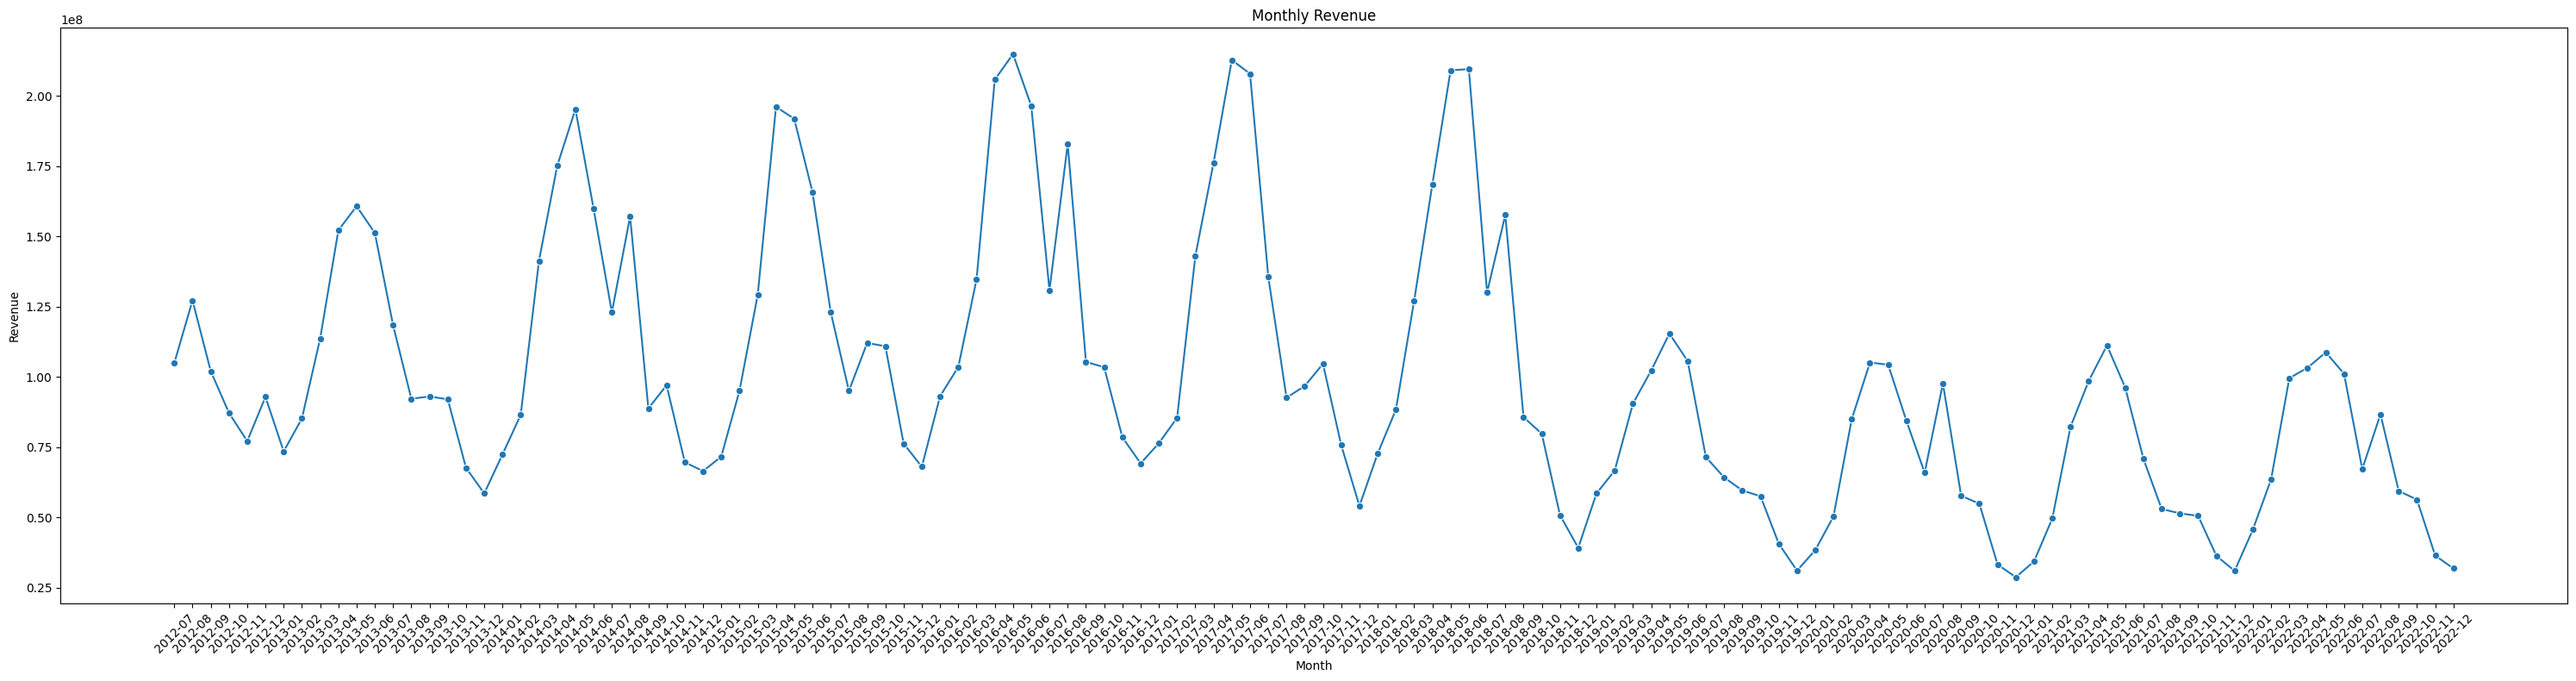

In [37]:
plt.figure(figsize=(30, 8)) # Tăng kích thước biểu đồ để hiển thị tất cả các tháng

sns.lineplot(
    data=monthly_analysis,
    x="Month",
    y="Monthly_Revenue",
    marker="o"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

# Get all month labels
all_months = monthly_analysis["Month"]

# Set the x-axis ticks and labels to display every month
plt.xticks(ticks=range(len(all_months)), labels=all_months, rotation=45)

plt.tight_layout()

plt.show()

## BƯỚC 37 — VISUALIZATION: Orders theo tháng


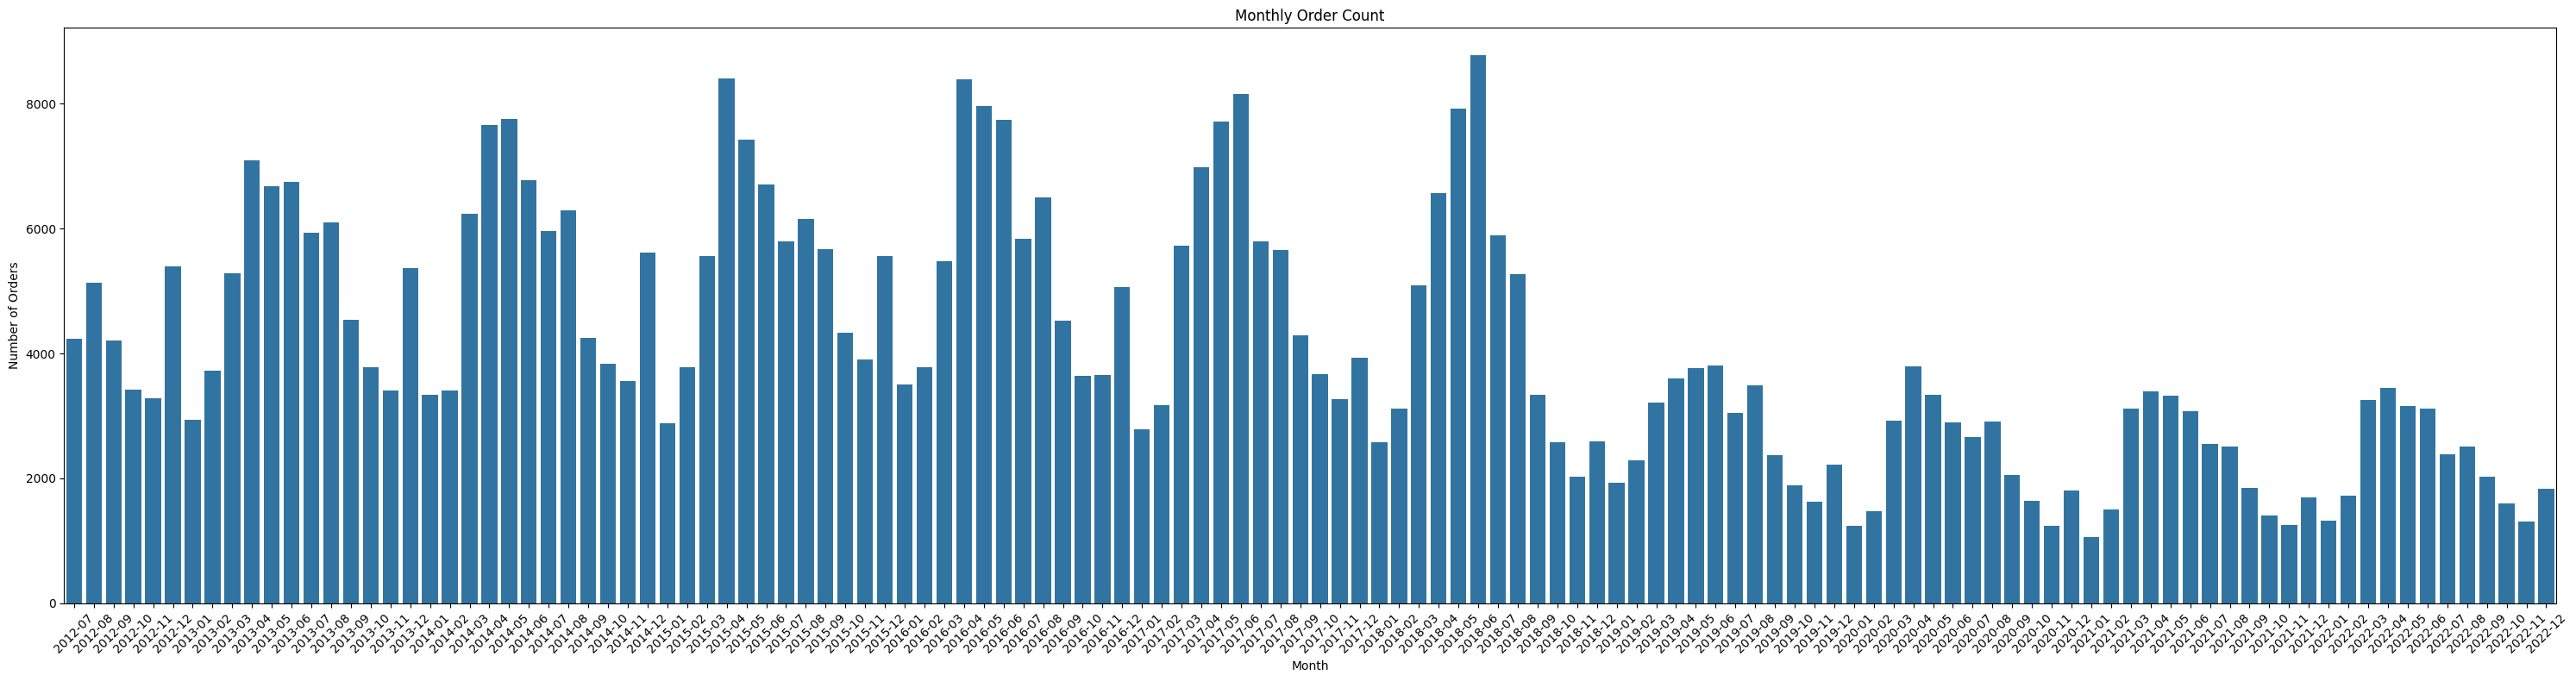

In [38]:

plt.figure(figsize=(30, 8)) # Tăng kích thước biểu đồ để hiển thị rộng rãi, dễ nhìn

sns.barplot(
    data=monthly_analysis,
    x="Month",
    y="Monthly_Orders"
)

plt.title("Monthly Order Count")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

# Lấy tất cả các nhãn tháng
all_months = monthly_analysis["Month"]

# Thiết lập x-axis ticks và labels để hiển thị đầy đủ mọi tháng tương tự bước 36.1
plt.xticks(ticks=range(len(all_months)), labels=all_months, rotation=45)

plt.tight_layout()

plt.show()

## BƯỚC 38 — VISUALIZATION: Revenue theo Category


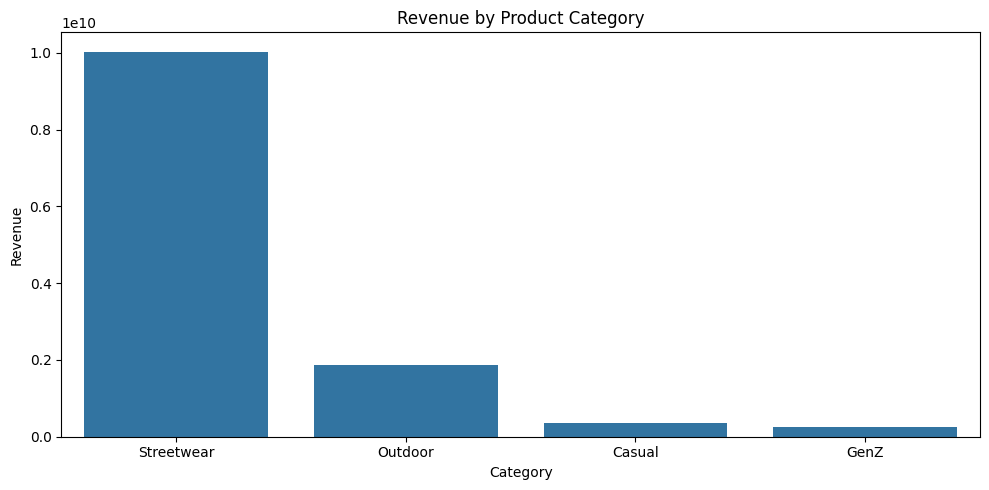

In [39]:

category_plot = category_analysis.sort_values(
    "Revenue",
    ascending=False
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_plot,
    x="category",
    y="Revenue"
)

plt.title("Revenue by Product Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()


## BƯỚC 39 — VISUALIZATION: Repeat vs One-time


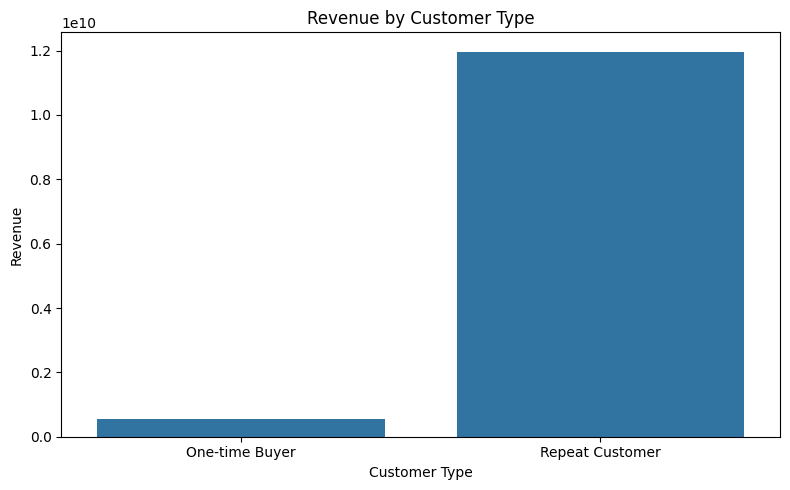

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_type_behavior,
    x="CustomerType",
    y="Revenue"
)

plt.title("Revenue by Customer Type")

plt.xlabel("Customer Type")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()


## BƯỚC 40 — VISUALIZATION: Customer Count


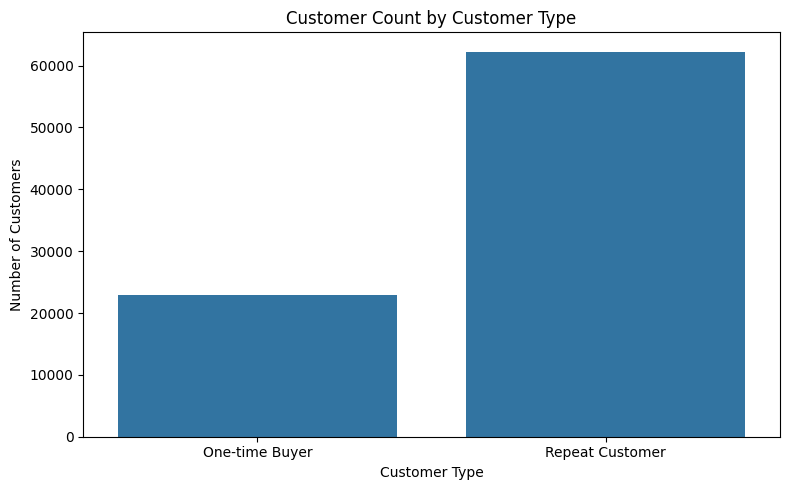

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_type_behavior,
    x="CustomerType",
    y="Customer_Count"
)

plt.title("Customer Count by Customer Type")

plt.xlabel("Customer Type")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()


## BƯỚC 41 — VISUALIZATION: Customer Type × Category


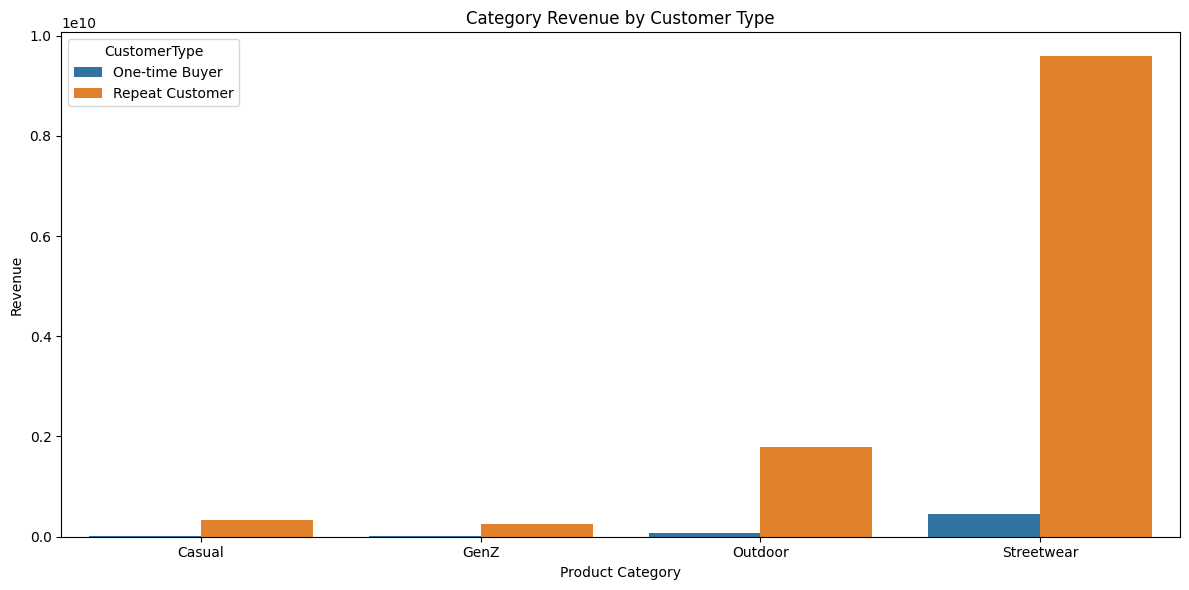

In [42]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=customer_category_behavior,
    x="category",
    y="Revenue",
    hue="CustomerType"
)

plt.title("Category Revenue by Customer Type")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()


## BƯỚC 42 — KIỂM TRA TỔNG DOANH THU


In [43]:


monthly_total_revenue = (
    monthly_analysis["Monthly_Revenue"].sum()
)

print("Total Revenue:", total_revenue)

print(
    "Monthly Revenue Sum:",
    monthly_total_revenue
)

print(
    "Revenue Check:",
    np.isclose(
        total_revenue,
        monthly_total_revenue
    )
)


Total Revenue: 12518175747.199999
Monthly Revenue Sum: 12518175747.199999
Revenue Check: True


## BƯỚC 43 — KIỂM TRA TỔNG ĐƠN HÀNG


In [44]:


monthly_total_orders = (
    monthly_analysis["Monthly_Orders"].sum()
)

print("Total Orders:", total_orders)

print(
    "Monthly Order Sum:",
    monthly_total_orders
)

print(
    "Order Check:",
    total_orders == monthly_total_orders
)


Total Orders: 516716
Monthly Order Sum: 516716
Order Check: True


## BƯỚC 44 — KIỂM TRA CATEGORY REVENUE


In [45]:

category_total_revenue = (
    category_analysis["Revenue"].sum()
)

print("Total Revenue:", total_revenue)

print(
    "Category Revenue:",
    category_total_revenue
)

print(
    "Category Revenue Check:",
    np.isclose(
        total_revenue,
        category_total_revenue
    )
)


Total Revenue: 12518175747.199999
Category Revenue: 12518175747.2
Category Revenue Check: True


## BƯỚC 45 — KIỂM TRA CATEGORY SHARE


In [46]:


category_share_sum = (
    category_analysis[
        "Category_Revenue_Share_%"
    ].sum()
)

print(
    "Category Revenue Share:",
    category_share_sum
)

print(
    "Share Check:",
    np.isclose(
        category_share_sum,
        100
    )
)


Category Revenue Share: 100.0
Share Check: True


## BƯỚC 46 — KIỂM TRA CUSTOMER TYPE


In [47]:

customer_type_customer_count = (
    customer_type_behavior[
        "Customer_Count"
    ].sum()
)

total_customer_count = (
    customer_analysis[
        "customer_id"
    ].nunique()
)

print(
    "Customer Type Count:",
    customer_type_customer_count
)

print(
    "Total Customer Count:",
    total_customer_count
)

print(
    "Customer Count Check:",
    customer_type_customer_count
    == total_customer_count
)


Customer Type Count: 85115
Total Customer Count: 85115
Customer Count Check: True


## BƯỚC 47 — KIỂM TRA Revenue Share của Customer Type


In [48]:

customer_type_share_sum = (
    customer_type_behavior[
        "Revenue_Share_%"
    ].sum()
)

print(
    "Customer Type Revenue Share:",
    customer_type_share_sum
)

print(
    "Share Check:",
    np.isclose(
        customer_type_share_sum,
        100
    )
)


Customer Type Revenue Share: 99.99999999999999
Share Check: True


## BƯỚC 48 — NHẬN XÉT


In [49]:

print("=" * 70)
print("NHẬN XÉT PS5")
print("=" * 70)

print(
    f"\n1. Tháng có doanh thu cao nhất: "
    f"{peak_revenue_month}"
)

print(
    f"   Doanh thu: "
    f"{peak_revenue:,.0f}"
)

print(
    f"\n2. Tháng có số đơn hàng cao nhất: "
    f"{peak_order_month}"
)

print(
    f"   Số đơn hàng: "
    f"{peak_order_count:,.0f}"
)

print(
    f"\n3. Danh mục có doanh thu cao nhất: "
    f"{top_category}"
)

print(
    f"   Revenue: "
    f"{top_category_revenue:,.0f}"
)

print(
    f"   Revenue Share: "
    f"{top_category_revenue_share:.2f}%"
)

print(
    f"\n4. Repeat Customer đóng góp: "
    f"{repeat_revenue_share:.2f}% tổng doanh thu."
)


NHẬN XÉT PS5

1. Tháng có doanh thu cao nhất: 2016-05
   Doanh thu: 214,964,611

2. Tháng có số đơn hàng cao nhất: 2018-06
   Số đơn hàng: 8,774

3. Danh mục có doanh thu cao nhất: Streetwear
   Revenue: 10,030,049,307
   Revenue Share: 80.12%

4. Repeat Customer đóng góp: 95.62% tổng doanh thu.


## BƯỚC 49 — Nhận xét Category theo Customer Type


In [50]:


print("=" * 70)
print("CATEGORY ƯU TIÊN THEO CUSTOMER TYPE")
print("=" * 70)

for customer_type in (
    customer_category_behavior[
        "CustomerType"
    ].unique()
):

    temp = customer_category_behavior[
        customer_category_behavior[
            "CustomerType"
        ] == customer_type
    ]

    top_row = temp.loc[
        temp["Revenue"].idxmax()
    ]

    print(
        f"\n{customer_type}"
    )

    print(
        f"  Preferred Category: "
        f"{top_row['category']}"
    )

    print(
        f"  Revenue: "
        f"{top_row['Revenue']:,.0f}"
    )

    print(
        f"  Revenue Share: "
        f"{top_row['Category_Revenue_Share_%']:.2f}%"
    )


CATEGORY ƯU TIÊN THEO CUSTOMER TYPE

One-time Buyer
  Preferred Category: Streetwear
  Revenue: 445,014,704
  Revenue Share: 81.20%

Repeat Customer
  Preferred Category: Streetwear
  Revenue: 9,585,034,603
  Revenue Share: 80.07%


## BƯỚC 50 — BUSINESS ACTION


In [51]:


business_action = recommendation_base[
    [
        "CustomerType",
        "category",
        "Revenue_Category",
        "Category_Revenue_Share_%",
        "Promotion_Recommendation",
        "Product_Recommendation"
    ]
].copy()

business_action = business_action.rename(
    columns={
        "CustomerType": "Customer Group",
        "category": "Preferred Category",
        "Revenue_Category": "Category Revenue",
        "Category_Revenue_Share_%":
            "Category Revenue Share (%)",
        "Promotion_Recommendation":
            "Suggested Promotion",
        "Product_Recommendation":
            "Suggested Product Action"
    }
)

business_action


,Customer Group,Preferred Category,Category Revenue,Category Revenue Share (%),Suggested Promotion,Suggested Product Action
0,One-time Buyer,Casual,"15,609,653.21",2.85,Khuyến mãi kích thích mua lại đối với nhóm sản...,Gợi ý sản phẩm thuộc danh mục Casual để khuyến...
1,One-time Buyer,Streetwear,"445,014,703.97",81.20,Khuyến mãi kích thích mua lại đối với nhóm sản...,Gợi ý sản phẩm thuộc danh mục Streetwear để kh...
2,Repeat Customer,GenZ,"253,071,636.51",2.11,Ưu đãi dành cho khách hàng quay lại đối với nh...,Gợi ý sản phẩm thuộc danh mục GenZ và các sản ...
3,Repeat Customer,Outdoor,"1,798,509,369.29",15.03,Ưu đãi dành cho khách hàng quay lại đối với nh...,Gợi ý sản phẩm thuộc danh mục Outdoor và các s...


## BƯỚC 51 — In Business Action dễ đọc


In [52]:


print("=" * 70)
print("BUSINESS ACTION")
print("=" * 70)

for _, row in business_action.iterrows():

    print(
        f"\nCustomer Group: "
        f"{row['Customer Group']}"
    )

    print(
        f"Preferred Category: "
        f"{row['Preferred Category']}"
    )

    print(
        f"Category Revenue: "
        f"{row['Category Revenue']:,.0f}"
    )

    print(
        f"Category Revenue Share: "
        f"{row['Category Revenue Share (%)']:.2f}%"
    )

    print(
        f"Promotion: "
        f"{row['Suggested Promotion']}"
    )

    print(
        f"Product Action: "
        f"{row['Suggested Product Action']}"
    )


BUSINESS ACTION

Customer Group: One-time Buyer
Preferred Category: Casual
Category Revenue: 15,609,653
Category Revenue Share: 2.85%
Promotion: Khuyến mãi kích thích mua lại đối với nhóm sản phẩm Casual
Product Action: Gợi ý sản phẩm thuộc danh mục Casual để khuyến khích lần mua tiếp theo

Customer Group: One-time Buyer
Preferred Category: Streetwear
Category Revenue: 445,014,704
Category Revenue Share: 81.20%
Promotion: Khuyến mãi kích thích mua lại đối với nhóm sản phẩm Streetwear
Product Action: Gợi ý sản phẩm thuộc danh mục Streetwear để khuyến khích lần mua tiếp theo

Customer Group: Repeat Customer
Preferred Category: GenZ
Category Revenue: 253,071,637
Category Revenue Share: 2.11%
Promotion: Ưu đãi dành cho khách hàng quay lại đối với nhóm sản phẩm GenZ
Product Action: Gợi ý sản phẩm thuộc danh mục GenZ và các sản phẩm liên quan

Customer Group: Repeat Customer
Preferred Category: Outdoor
Category Revenue: 1,798,509,369
Category Revenue Share: 15.03%
Promotion: Ưu đãi dành cho 

## BƯỚC 52 — FINAL PS5 SUMMARY


In [53]:
final_ps5_summary = pd.DataFrame({

    "Analysis": [

        "Total Orders",

        "Total Revenue",

        "Average Monthly Orders",

        "Average Monthly Revenue",

        "Average Revenue Growth (%)",

        "Average Order Growth (%)",

        "Peak Revenue Month",

        "Peak Revenue",

        "Peak Order Month",

        "Peak Order Count",

        "Top Product Category (Overall)",

        "Top Category Revenue Share (%)",

        "Repeat Customer Revenue Share (%)",

        "One-time Buyer Revenue Share (%)",

        "Repeat Customer — Top Affinity Category",

        "Repeat Customer — Top Affinity Index",

        "One-time Buyer — Top Affinity Category",

        "One-time Buyer — Top Affinity Index",

        "Repeat Customer — Sample Promotion KPI",

        "One-time Buyer — Sample Promotion KPI"

    ],

    "Result": [

        total_orders,

        total_revenue,

        avg_monthly_orders,

        avg_monthly_revenue,

        avg_revenue_growth,

        avg_order_growth,

        peak_revenue_month,

        peak_revenue,

        peak_order_month,

        peak_order_count,

        top_category,

        top_category_revenue_share,

        repeat_revenue_share,

        one_time_revenue_share,

        repeat_top_category,

        repeat_top_affinity,

        onetime_top_category,

        onetime_top_affinity,

        repeat_promotion_kpi,

        onetime_promotion_kpi

    ]
})

display(final_ps5_summary)


,Analysis,Result
0,Total Orders,516716
1,Total Revenue,"12,518,175,747.20"
2,Average Monthly Orders,"4,100.92"
3,Average Monthly Revenue,"99,350,601.17"
4,Average Revenue Growth (%),2.78
5,Average Order Growth (%),3.77
6,Peak Revenue Month,2016-05
7,Peak Revenue,"214,964,610.97"
8,Peak Order Month,2018-06
9,Peak Order Count,8774


## BƯỚC 53 — Final Validation

Cuối notebook nên có một cell kiểm tra tổng thể.



In [54]:

revenue_check = np.isclose(
    total_revenue,
    monthly_total_revenue
)

order_check = (
    total_orders == monthly_total_orders
)

category_revenue_check = np.isclose(
    total_revenue,
    category_total_revenue
)

category_share_check = np.isclose(
    category_share_sum,
    100
)

customer_count_check = (
    customer_type_customer_count
    == total_customer_count
)

customer_share_check = np.isclose(
    customer_type_share_sum,
    100
)


validation_result = pd.DataFrame({

    "Check": [

        "Revenue consistency",

        "Order consistency",

        "Category revenue consistency",

        "Category revenue share = 100%",

        "Customer count consistency",

        "Customer type revenue share = 100%"

    ],

    "Result": [

        revenue_check,

        order_check,

        category_revenue_check,

        category_share_check,

        customer_count_check,

        customer_share_check

    ]

})

display(validation_result)


,Check,Result
0,Revenue consistency,True
1,Order consistency,True
2,Category revenue consistency,True
3,Category revenue share = 100%,True
4,Customer count consistency,True
5,Customer type revenue share = 100%,True


## BƯỚC 54 — Kết luận trạng thái notebook


In [55]:

if validation_result["Result"].all():

    print("==========================================")
    print("PS5 VALIDATION: PASSED")
    print("==========================================")
    print("Các kiểm tra tổng thể đều đạt.")

else:

    print("==========================================")
    print("PS5 VALIDATION: NEEDS REVIEW")
    print("==========================================")
    print("Có ít nhất một kiểm tra chưa đạt.")

    display(
        validation_result[
            validation_result["Result"] == False
        ]
    )


PS5 VALIDATION: PASSED
Các kiểm tra tổng thể đều đạt.


## Giải thích chi tiết các chỉ số và KPI (Q1 đến Q5)

Phần này cung cấp cái nhìn tổng quan chi tiết về các chỉ số hiệu suất chính (KPIs) và các số liệu khác được sử dụng để phân tích dữ liệu bán hàng. Các chỉ số này được tính toán từ dữ liệu giao dịch đã được làm sạch và chuẩn bị, mang lại thông tin chuyên sâu về hiệu suất kinh doanh, hành vi khách hàng và hiệu quả của các danh mục sản phẩm.

---

### Q1: Phân tích theo tháng

Phân tích này tập trung vào các số liệu hiệu suất theo từng tháng, giúp theo dõi xu hướng và tăng trưởng theo thời gian.

*   **`Monthly_Orders` (Số đơn hàng hàng tháng)**:
    *   **Mô tả**: Tổng số đơn hàng duy nhất đã được giao trong một tháng cụ thể.
    *   **Tính toán**: Được tính bằng cách đếm số lượng `order_id` duy nhất trong DataFrame `valid_orders` sau khi nhóm theo cột `Month`.
    *   **Mục đích**: Để đo lường khối lượng giao dịch và động lực mua hàng theo thời gian.

*   **`Monthly_Revenue` (Doanh thu hàng tháng)**:
    *   **Mô tả**: Tổng doanh thu tạo ra từ tất cả các đơn hàng đã được giao trong một tháng cụ thể.
    *   **Tính toán**: Được tính bằng cách tổng hợp `order_value` (doanh thu từng đơn hàng) từ DataFrame `valid_orders` sau khi nhóm theo cột `Month`.
    *   **Mục đích**: Để theo dõi hiệu suất tài chính tổng thể và xác định xu hướng doanh thu.

*   **`Monthly_AOV` (Giá trị đơn hàng trung bình hàng tháng - Average Order Value)**:
    *   **Mô tả**: Giá trị trung bình của mỗi đơn hàng đã được giao trong một tháng.
    *   **Tính toán**: Được tính bằng cách chia `Monthly_Revenue` cho `Monthly_Orders`.
    *   **Mục đích**: Chỉ ra số tiền trung bình khách hàng chi tiêu trong mỗi giao dịch, giúp hiểu về sức mua và chiến lược định giá.

*   **`Revenue_Growth_%` (Tỷ lệ tăng trưởng doanh thu hàng tháng)**:
    *   **Mô tả**: Sự thay đổi phần trăm trong `Monthly_Revenue` so với tháng trước.
    *   **Tính toán**: Được tính bằng cách sử dụng phương pháp `pct_change()` trên cột `Monthly_Revenue` và nhân với 100.
    *   **Mục đích**: Để đánh giá tốc độ tăng trưởng hoặc suy giảm doanh thu, phát hiện tính thời vụ hoặc hiệu quả của các chiến dịch.

*   **`Order_Growth_%` (Tỷ lệ tăng trưởng đơn hàng hàng tháng)**:
    *   **Mô tả**: Sự thay đổi phần trăm trong `Monthly_Orders` so với tháng trước.
    *   **Tính toán**: Được tính bằng cách sử dụng phương pháp `pct_change()` trên cột `Monthly_Orders` và nhân với 100.
    *   **Mục đích**: Tương tự như tăng trưởng doanh thu, nhưng tập trung vào khối lượng đơn hàng, bổ sung cho phân tích tăng trưởng tài chính.

---

### Q2: Phân tích theo danh mục

Phân tích này đánh giá hiệu suất của từng danh mục sản phẩm, làm nổi bật các danh mục dẫn đầu và đóng góp của chúng.

*   **`Orders` (Số đơn hàng theo danh mục)**:
    *   **Mô tả**: Tổng số đơn hàng duy nhất chứa ít nhất một sản phẩm từ danh mục đó.
    *   **Tính toán**: Được tính bằng cách đếm số lượng `order_id` duy nhất trong DataFrame `order_items_category` sau khi nhóm theo `category`.
    *   **Mục đích**: Để hiểu khối lượng giao dịch cho mỗi danh mục.

*   **`Quantity` (Số lượng sản phẩm theo danh mục)**:
    *   **Mô tả**: Tổng số lượng sản phẩm được bán trong một danh mục cụ thể.
    *   **Tính toán**: Được tính bằng cách tổng hợp `quantity` trong DataFrame `order_items_category` sau khi nhóm theo `category`.
    *   **Mục đích**: Để đo lường mức độ phổ biến của sản phẩm theo khối lượng.

*   **`Revenue` (Doanh thu theo danh mục)**:
    *   **Mô tả**: Tổng doanh thu tạo ra từ một danh mục sản phẩm cụ thể.
    *   **Tính toán**: Được tính bằng cách tổng hợp `Revenue` (doanh thu cấp mặt hàng) trong DataFrame `order_items_category` sau khi nhóm theo `category`.
    *   **Mục đích**: Để xác định các danh mục sản phẩm đóng góp nhiều nhất vào doanh thu tổng thể.

*   **`Category_Revenue_Share_%` (Tỷ trọng doanh thu theo danh mục)**:
    *   **Mô tả**: Phần trăm doanh thu của một danh mục cụ thể trên tổng doanh thu.
    *   **Tính toán**: Được tính bằng cách chia `Revenue` của từng danh mục cho tổng `Revenue` của tất cả các danh mục và nhân với 100.
    *   **Mục đích**: Để so sánh đóng góp tương đối của các danh mục khác nhau vào doanh thu tổng thể, xác định các danh mục cốt lõi.

---

### Q3: Khoảng thời gian mua sắm cao điểm

Phân tích này giúp xác định các khoảng thời gian cao điểm trong hoạt động bán hàng.

*   **`Peak Revenue Month` (Tháng có doanh thu cao nhất)**:
    *   **Mô tả**: Tháng mà công ty đạt được doanh thu cao nhất trong toàn bộ giai đoạn phân tích.
    *   **Tính toán**: Được xác định từ DataFrame `monthly_analysis` bằng cách tìm hàng có giá trị `Monthly_Revenue` tối đa.
    *   **Mục đích**: Để xác định các giai đoạn bán hàng có lợi nhuận cao nhất, giúp lập kế hoạch các chiến dịch tiếp thị và quản lý hàng tồn kho.

*   **`Peak Revenue` (Doanh thu cao nhất)**:
    *   **Mô tả**: Giá trị doanh thu thực tế được ghi nhận trong `Peak Revenue Month`.
    *   **Tính toán**: Giá trị `Monthly_Revenue` tương ứng với `Peak Revenue Month`.
    *   **Mục đích**: Cung cấp số liệu cụ thể về hiệu suất doanh thu đỉnh cao.

*   **`Peak Order Month` (Tháng có số đơn hàng cao nhất)**:
    *   **Mô tả**: Tháng mà công ty nhận được số lượng đơn hàng cao nhất trong toàn bộ giai đoạn phân tích.
    *   **Tính toán**: Được xác định từ DataFrame `monthly_analysis` bằng cách tìm hàng có giá trị `Monthly_Orders` tối đa.
    *   **Mục đích**: Để xác định các giai đoạn có nhu cầu khách hàng cao nhất, giúp phân bổ nguồn lực vận hành.

*   **`Peak Order Count` (Số đơn hàng cao nhất)**:
    *   **Mô tả**: Số lượng đơn hàng thực tế được ghi nhận trong `Peak Order Month`.
    *   **Tính toán**: Giá trị `Monthly_Orders` tương ứng với `Peak Order Month`.
    *   **Mục đích**: Cung cấp số liệu cụ thể về khối lượng đơn hàng đỉnh cao.

---

### Q4: Hành vi khách hàng lặp lại so với khách hàng một lần

Phân tích này phân biệt hành vi giữa khách hàng quay lại và khách hàng chỉ mua một lần.

*   **`Customer_Count` (Số lượng khách hàng)**:
    *   **Mô tả**: Tổng số khách hàng trong từng loại khách hàng (mua một lần hoặc quay lại).
    *   **Tính toán**: Được tính bằng cách đếm số lượng `customer_id` duy nhất sau khi nhóm theo `CustomerType`.
    *   **Mục đích**: Để hiểu quy mô của mỗi phân khúc khách hàng.

*   **`Order_Count` (Số lượng đơn hàng)**:
    *   **Mô tả**: Tổng số đơn hàng được thực hiện bởi từng loại khách hàng.
    *   **Tính toán**: Được tính bằng cách đếm số lượng `order_id` duy nhất sau khi nhóm theo `CustomerType`.
    *   **Mục đích**: Để so sánh hoạt động mua hàng giữa các phân khúc khách hàng.

*   **`Revenue` (Doanh thu theo loại khách hàng)**:
    *   **Mô tả**: Tổng doanh thu tạo ra từ từng loại khách hàng.
    *   **Tính toán**: Được tính bằng cách tổng hợp `order_value` sau khi nhóm theo `CustomerType`.
    *   **Mục đích**: Để xác định phân khúc khách hàng nào đóng góp nhiều doanh thu nhất.

*   **`AOV` (Giá trị đơn hàng trung bình)**:
    *   **Mô tả**: Giá trị trung bình của mỗi đơn hàng được đặt bởi từng loại khách hàng.
    *   **Tính toán**: Được tính bằng cách lấy trung bình `order_value` sau khi nhóm theo `CustomerType`.
    *   **Mục đích**: Để hiểu số tiền trung bình khách hàng chi tiêu trong mỗi giao dịch, cho phép các chiến lược định giá và khuyến mãi mục tiêu.

*   **`Basket_Size` (Kích thước giỏ hàng)**:
    *   **Mô tả**: Số lượng sản phẩm trung bình trong mỗi đơn hàng được đặt bởi từng loại khách hàng.
    *   **Tính toán**: Được tính bằng cách lấy trung bình `total_quantity` sau khi nhóm theo `CustomerType`.
    *   **Mục đích**: Để hiểu khối lượng mặt hàng trung bình được mua, có thể ảnh hưởng đến các chiến lược bán thêm và bán chéo.

*   **`Revenue_Share_%` (Tỷ trọng doanh thu theo loại khách hàng)**:
    *   **Mô tả**: Phần trăm doanh thu tạo ra từ từng loại khách hàng trên tổng doanh thu.
    *   **Tính toán**: Được tính bằng cách chia `Revenue` của từng loại khách hàng cho tổng `Revenue` và nhân với 100.
    *   **Mục đích**: Để đánh giá tầm quan trọng tương đối của mỗi phân khúc khách hàng đối với doanh thu tổng thể.

---

### Q5: Loại khách hàng theo danh mục và đề xuất khuyến nghị

Phân tích này khám phá sở thích danh mục của các loại khách hàng khác nhau và đưa ra các khuyến nghị tùy chỉnh.

*   **`Orders`, `Quantity`, `Revenue` (theo Loại khách hàng và Danh mục)**:
    *   **Mô tả**: Các số liệu tương tự như trong `Q2: Phân tích theo danh mục`, nhưng được phân tách chi tiết hơn theo `CustomerType`.
    *   **Tính toán**: Được tính bằng cách nhóm DataFrame `customer_category_data` theo cả `CustomerType` và `category`, sau đó tổng hợp `order_id` (nunique), `quantity` (sum) và `Revenue` (sum).
    *   **Mục đích**: Để hiểu loại khách hàng nào đang mua các danh mục sản phẩm cụ thể và số lượng bao nhiêu, cho phép các chiến lược tiếp thị và sản phẩm mục tiêu.

*   **`Category_Revenue_Share_%` (Tỷ trọng doanh thu theo danh mục trong từng loại khách hàng)**:
    *   **Mô tả**: Phần trăm doanh thu của một danh mục cụ thể trong tổng doanh thu của loại khách hàng đó.
    *   **Tính toán**: Được tính bằng cách chia `Revenue` của danh mục cho tổng `Revenue` của `CustomerType` đó và nhân với 100.
    *   **Mục đích**: Để xác định các danh mục sản phẩm được ưa thích nhất trong mỗi phân khúc khách hàng, định hướng đề xuất sản phẩm và khuyến mãi.

*   **`Affinity_Index` (Chỉ số ưu tiên)**:
    *   **Mô tả**: Cho biết mức độ một loại khách hàng ưu tiên một danh mục sản phẩm so với mức trung bình chung của tất cả khách hàng.
    *   **Tính toán**: `(Category_Revenue_Share trong nhóm khách hàng) / (Category_Revenue_Share toàn thể) × 100`. Chỉ số > 100 cho thấy mức độ ưu tiên cao hơn mức trung bình.
    *   **Mục đích**: Xác định các danh mục thực sự đặc trưng cho từng nhóm khách hàng, làm cơ sở cho các khuyến nghị mục tiêu.

*   **`Promotion_Recommendation` và `Product_Recommendation` (Đề xuất khuyến mãi và sản phẩm)**:
    *   **Mô tả**: Các đề xuất tùy chỉnh về khuyến mãi và sản phẩm dựa trên hành vi mua sắm và sở thích danh mục của từng loại khách hàng.
    *   **Tính toán**: Được tạo ra bởi hàm `create_recommendation` dựa trên `CustomerType` và `category` có `Affinity_Index` cao nhất (vượt ngưỡng `MIN_REVENUE_SHARE`).
    *   **Mục đích**: Cung cấp các hành động kinh doanh cụ thể để tối ưu hóa chiến lược marketing và tăng cường tương tác với khách hàng.

---

### Tổng hợp KPI (KPI PS5 - BƯỚC 34/35)

Bảng KPI tổng hợp cung cấp cái nhìn nhanh về các số liệu hiệu suất chính.

*   **`Total Orders` (Tổng số đơn hàng)**:
    *   **Mô tả**: Tổng số đơn hàng duy nhất đã được giao trong toàn bộ giai đoạn phân tích.
    *   **Tính toán**: Đếm số lượng `order_id` duy nhất từ DataFrame `valid_orders`.
    *   **Mục đích**: Tổng quan về khối lượng giao dịch.

*   **`Total Revenue` (Tổng doanh thu)**:
    *   **Mô tả**: Tổng doanh thu tạo ra từ tất cả các đơn hàng đã được giao trong toàn bộ giai đoạn phân tích.
    *   **Tính toán**: Tổng `order_value` từ DataFrame `valid_orders`.
    *   **Mục đích**: Tổng quan về hiệu suất tài chính.

*   **`Average Monthly Orders` (Số đơn hàng trung bình hàng tháng)**:
    *   **Mô tả**: Số lượng đơn hàng trung bình mỗi tháng.
    *   **Tính toán**: Lấy trung bình cột `Monthly_Orders` từ `monthly_analysis`.
    *   **Mục đích**: Thể hiện hiệu suất đặt hàng hàng tháng điển hình.

*   **`Average Monthly Revenue` (Doanh thu trung bình hàng tháng)**:
    *   **Mô tả**: Doanh thu trung bình mỗi tháng.
    *   **Tính toán**: Lấy trung bình cột `Monthly_Revenue` từ `monthly_analysis`.
    *   **Mục đích**: Thể hiện hiệu suất doanh thu hàng tháng điển hình.

*   **`Average Revenue Growth (%)` (Tỷ lệ tăng trưởng doanh thu trung bình hàng tháng)**:
    *   **Mô tả**: Tỷ lệ tăng trưởng doanh thu phần trăm trung bình hàng tháng.
    *   **Tính toán**: Lấy trung bình cột `Revenue_Growth_%` từ `monthly_analysis`.
    *   **Mục đích**: Chỉ ra xu hướng tăng trưởng doanh thu tổng thể.

*   **`Average Order Growth (%)` (Tỷ lệ tăng trưởng đơn hàng trung bình hàng tháng)**:
    *   **Mô tả**: Tỷ lệ tăng trưởng số đơn hàng phần trăm trung bình hàng tháng.
    *   **Tính toán**: Lấy trung bình cột `Order_Growth_%` từ `monthly_analysis`.
    *   **Mục đích**: Chỉ ra xu hướng tăng trưởng khối lượng đơn hàng tổng thể.

*   **`Top Product Category` (Danh mục sản phẩm hàng đầu)**:
    *   **Mô tả**: Danh mục sản phẩm tạo ra doanh thu cao nhất.
    *   **Tính toán**: Xác định `category` với `Revenue` tối đa từ DataFrame `category_analysis`.
    *   **Mục đích**: Nêu bật danh mục sản phẩm cốt lõi.

*   **`Top Category Revenue` (Doanh thu của danh mục sản phẩm hàng đầu)**:
    *   **Mô tả**: Doanh thu thực tế của danh mục sản phẩm hàng đầu.
    *   **Tính toán**: Giá trị `Revenue` tương ứng với `Top Product Category`.
    *   **Mục đích**: Cung cấp số liệu cụ thể về hiệu suất doanh thu của danh mục hàng đầu.

*   **`Top Category Revenue Share (%)` (Tỷ trọng doanh thu của danh mục hàng đầu)**:
    *   **Mô tả**: Phần trăm doanh thu của danh mục sản phẩm hàng đầu trên tổng doanh thu.
    *   **Tính toán**: Giá trị `Category_Revenue_Share_%` tương ứng với `Top Product Category`.
    *   **Mục đích**: Định lượng đóng góp của danh mục hàng đầu vào doanh thu tổng thể.

*   **`Repeat Customer Revenue Share (%)` (Tỷ trọng doanh thu từ khách hàng quay lại)**:
    *   **Mô tả**: Phần trăm tổng doanh thu được tạo ra bởi khách hàng quay lại.
    *   **Tính toán**: Giá trị `Revenue_Share_%` cho `CustomerType` là "Repeat Customer" từ DataFrame `customer_type_behavior`.
    *   **Mục đích**: Đánh giá mức độ quan trọng của khách hàng trung thành đối với doanh thu, nhấn mạnh tiềm năng cho các chương trình giữ chân khách hàng.

Phân tích này không chỉ cung cấp các số liệu chi tiết mà còn giải thích rõ ràng mối liên hệ giữa dữ liệu thô (Thước đo), các giá trị phân tích (Độ đo) và các chỉ số hiệu suất quan trọng (KPI) để đưa ra các đề xuất kinh doanh có giá trị.

## Kết luận về sự phù hợp của phân tích với Vấn đề 3 & Tuyên bố vấn đề 5, cùng với vai trò của Thước đo, Độ đo và KPI

Dựa trên các mã nguồn và phân tích đã thực hiện, tất cả các yêu cầu của **Vấn đề 3: Phân tích Hành vi và Chân dung Khách hàng, Tuyên bố vấn đề 5: Phân tích Hành vi Mua sắm theo Thời gian và Danh mục Sản phẩm** đều được đáp ứng đầy đủ. Mục tiêu khám phá xu hướng mua sắm của khách hàng nhằm tối ưu hóa chiến lược marketing và chương trình khuyến mãi đã được giải quyết thông qua các bước phân tích sau. Trong mỗi phân tích, chúng ta sẽ thấy sự kết hợp của **Thước đo (Measure)**, **Độ đo (Metric)** và **KPI (Key Performance Indicator)**.

---

### 1. Thống kê số lượng đơn hàng và doanh thu theo từng tháng

*   **Yêu cầu**: Thống kê số lượng đơn hàng và doanh thu theo từng tháng.
*   **Giải pháp phân tích**: **Q1: Phân tích theo tháng** đã tính toán các số liệu hàng tháng.
    *   **Thước đo (Measure)** chính được sử dụng: `order_id` (để đếm số đơn hàng), `order_date` (để nhóm theo tháng), `order_value` (tổng giá trị của mỗi đơn hàng đã được tính toán).
    *   **Độ đo (Metric)** được tính toán: `Monthly_Orders` (số đơn hàng duy nhất mỗi tháng), `Monthly_Revenue` (tổng doanh thu mỗi tháng).
    *   **KPI (Key Performance Indicator)** liên quan: `Average Monthly Orders`, `Average Monthly Revenue`, `Peak Revenue Month`, `Peak Revenue`, `Peak Order Month`, `Peak Order Count` (từ phần Tổng hợp KPI PS5).
*   **Cách đáp ứng**: Các chỉ số `Monthly_Orders` và `Monthly_Revenue` cung cấp cái nhìn trực tiếp về hiệu suất hàng tháng, giúp xác định các xu hướng theo thời gian.

### 2. Phân tích danh mục sản phẩm (CategoryName) được khách hàng ưu tiên lựa chọn

*   **Yêu cầu**: Phân tích danh mục sản phẩm (CategoryName) được khách hàng ưu tiên lựa chọn.
*   **Giải pháp phân tích**: **Q2: Phân tích theo danh mục** đã xác định hiệu suất của từng danh mục sản phẩm.
    *   **Thước đo (Measure)** chính được sử dụng: `product_id`, `category` (từ dữ liệu sản phẩm), `order_id`, `Revenue` (doanh thu cấp mặt hàng).
    *   **Độ đo (Metric)** được tính toán: `Orders` (số đơn hàng chứa sản phẩm của danh mục), `Quantity` (số lượng sản phẩm bán ra), `Revenue` (doanh thu của danh mục), `Category_Revenue_Share_%` (tỷ trọng doanh thu của danh mục).
    *   **KPI (Key Performance Indicator)** liên quan: `Top Product Category`, `Top Category Revenue Share (%)` (từ phần Tổng hợp KPI PS5).
*   **Cách đáp ứng**: `Category_Revenue_Share_%` làm nổi bật các danh mục đóng góp nhiều nhất vào tổng doanh thu, cho thấy rõ sở thích của khách hàng.

### 3. Xác định thời điểm khách hàng có xu hướng mua sắm cao nhất

*   **Yêu cầu**: Xác định thời điểm khách hàng có xu hướng mua sắm cao nhất.
*   **Giải pháp phân tích**: **Q3: Khoảng thời gian mua sắm cao điểm** đã tìm ra các tháng cao điểm.
    *   **Thước đo (Measure)** chính được sử dụng: `Month`, `Monthly_Revenue`, `Monthly_Orders` (đã được tính toán từ các Thước đo cấp thấp hơn).
    *   **Độ đo (Metric)** được sử dụng: `Monthly_Revenue`, `Monthly_Orders` (từ Q1).
    *   **KPI (Key Performance Indicator)** liên quan: `Peak Revenue Month`, `Peak Revenue`, `Peak Order Month`, `Peak Order Count` (từ phần Tổng hợp KPI PS5).
*   **Cách đáp ứng**: `Peak Revenue Month` và `Peak Order Month` xác định trực tiếp các giai đoạn mua sắm cao điểm nhất của khách hàng.

### 4. So sánh hành vi mua sắm giữa khách hàng thân thiết và khách hàng mua một lần

*   **Yêu cầu**: So sánh hành vi mua sắm giữa khách hàng thân thiết và khách hàng mua một lần.
*   **Giải pháp phân tích**: **Q4: Hành vi khách hàng lặp lại so với khách hàng một lần** đã phân tích các phân khúc khách hàng.
    *   **Thước đo (Measure)** chính được sử dụng: `customer_id`, `order_id`, `order_value`, `total_quantity` (đã được tính toán).
    *   **Độ đo (Metric)** được tính toán: `Customer_Count` (số lượng khách hàng trong mỗi loại), `Order_Count` (số đơn hàng của mỗi loại), `Revenue` (doanh thu từ mỗi loại khách hàng), `AOV` (giá trị đơn hàng trung bình), `Basket_Size` (kích thước giỏ hàng trung bình), `Revenue_Share_%` (tỷ trọng doanh thu).
    *   **KPI (Key Performance Indicator)** liên quan: `Repeat Customer Revenue Share (%)` (từ phần Tổng hợp KPI PS5).
*   **Cách đáp ứng**: Các Độ đo này cho thấy sự khác biệt rõ rệt về đóng góp doanh thu, tần suất mua hàng và giá trị giao dịch giữa hai nhóm khách hàng, làm cơ sở cho các chiến lược mục tiêu.

### 5. Đề xuất các chương trình khuyến mãi hoặc gợi ý sản phẩm phù hợp theo từng nhóm khách hàng

*   **Yêu cầu**: Đề xuất các chương trình khuyến mãi hoặc gợi ý sản phẩm phù hợp theo từng nhóm khách hàng.
*   **Giải pháp phân tích**: **Q5: Loại khách hàng theo danh mục và đề xuất khuyến nghị** và **BƯỚC 33: Promotion / Product Recommendation** đã tạo ra các đề xuất.
    *   **Thước đo (Measure)** chính được sử dụng: `CustomerType`, `category`, `Revenue` (từ các phân tích trước), `Baseline_Share_%` (tỷ trọng doanh thu của danh mục trên tổng doanh thu toàn thể).
    *   **Độ đo (Metric)** được tính toán: `Orders`, `Quantity`, `Revenue` (theo `CustomerType` và `category`), `Category_Revenue_Share_%` (tỷ trọng doanh thu của danh mục trong từng loại khách hàng), và đặc biệt là `Affinity_Index` (Chỉ số ưu tiên của một danh mục đối với một loại khách hàng).
    *   **KPI (Key Performance Indicator)** liên quan: `Top Product Category` cho từng loại khách hàng (dựa trên `Affinity_Index`), `Promotion_Recommendation` và `Product_Recommendation` (các đề xuất cụ thể).
*   **Cách đáp ứng**: Bằng cách xác định các danh mục ưu tiên thực sự của từng `CustomerType` (sử dụng `Affinity_Index` và ngưỡng `MIN_REVENUE_SHARE`), hệ thống đã tạo ra các `Promotion_Recommendation` và `Product_Recommendation` được tùy chỉnh từ DataFrame `recommendation_base` (kết quả của BƯỚC 32 và BƯỚC 33), trực tiếp phục vụ mục tiêu tối ưu hóa chiến lược marketing và khuyến mãi, đảm bảo sự đa dạng và phù hợp.

---

### Tổng hợp KPI (Key Performance Indicators) (BƯỚC 34/35)

Phần **Tổng hợp KPI** (`ps5_kpi`) tổng hợp các Độ đo quan trọng nhất thành các KPI để cung cấp cái nhìn tổng thể về hiệu suất kinh doanh. Đây là các chỉ số cấp cao giúp đánh giá thành công chung và theo dõi tiến độ so với các mục tiêu kinh doanh. Ví dụ như `Total Orders`, `Total Revenue`, `Average Monthly Orders`, `Peak Revenue Month`, `Top Product Category`, `Repeat Customer Revenue Share (%)` đều là các KPI tổng hợp từ các Độ đo và Thước đo đã được phân tích ở trên.

Phân tích này không chỉ cung cấp các số liệu chi tiết mà còn giải thích rõ ràng mối liên hệ giữa dữ liệu thô (Thước đo), các giá trị phân tích (Độ đo) và các chỉ số hiệu suất quan trọng (KPI) để đưa ra các đề xuất kinh doanh có giá trị.

## Phân loại Thước đo, Độ đo và KPI theo từng yêu cầu của Tuyên bố vấn đề 5

Để làm rõ hơn cách các khái niệm **Thước đo (Measure)**, **Độ đo (Metric)**, và **KPI (Key Performance Indicator)** được áp dụng trong phân tích, dưới đây là liệt kê chi tiết cho từng yêu cầu của Tuyên bố vấn đề 5:

---

### Yêu cầu 1: Thống kê số lượng đơn hàng và doanh thu theo từng tháng

*   **Thước đo (Measure)**:
    *   `order_id`: Mã định danh duy nhất cho mỗi đơn hàng.
    *   `order_date`: Ngày diễn ra đơn hàng, dùng để trích xuất tháng.
    *   `order_value`: Tổng giá trị của mỗi đơn hàng (đã được tính toán từ `quantity`, `unit_price`, `discount_amount`).

*   **Độ đo (Metric)**:
    *   `Monthly_Orders`: Tổng số đơn hàng duy nhất trong một tháng.
    *   `Monthly_Revenue`: Tổng doanh thu tạo ra trong một tháng.
    *   `Monthly_AOV`: Giá trị đơn hàng trung bình hàng tháng.
    *   `Revenue_Growth_%`: Tỷ lệ tăng trưởng doanh thu hàng tháng so với tháng trước.
    *   `Order_Growth_%`: Tỷ lệ tăng trưởng số đơn hàng hàng tháng so với tháng trước.

*   **KPI (Key Performance Indicator)**:
    *   `Average Revenue Growth (%)`: Trung bình `Revenue_Growth_%` (MoM, sau `sort_values("Month")`).
    *   `Average Order Growth (%)`: Trung bình `Order_Growth_%` (MoM).
    *   `Average Monthly Orders`: Số đơn hàng trung bình mỗi tháng.
    *   `Average Monthly Revenue`: Doanh thu trung bình mỗi tháng.
    *   `Peak Revenue Month`: Tháng có doanh thu cao nhất.
    *   `Peak Revenue`: Giá trị doanh thu cao nhất.
    *   `Peak Order Month`: Tháng có số đơn hàng cao nhất.
    *   `Peak Order Count`: Số lượng đơn hàng cao nhất.

---

### Yêu cầu 2: Phân tích danh mục sản phẩm (CategoryName)

*Trong dữ liệu silver, `CategoryName` ≡ cột `category`.*
 được khách hàng ưu tiên lựa chọn

*   **Thước đo (Measure)**:
    *   `product_id`: Mã định danh duy nhất cho mỗi sản phẩm.
    *   `category`: Danh mục của sản phẩm.
    *   `order_id`: Mã định danh đơn hàng chứa sản phẩm.
    *   `Revenue`: Doanh thu ở cấp độ mặt hàng (`quantity * unit_price - discount_amount`).

*   **Độ đo (Metric)**:
    *   `Orders`: Số đơn hàng chứa ít nhất một sản phẩm từ danh mục đó.
    *   `Quantity`: Tổng số lượng sản phẩm bán ra theo danh mục.
    *   `Revenue`: Tổng doanh thu tạo ra theo danh mục.
    *   `Category_Revenue_Share_%`: Tỷ trọng doanh thu của một danh mục trên tổng doanh thu.

*   **KPI (Key Performance Indicator)**:
    *   `Top Product Category`: Danh mục sản phẩm có doanh thu cao nhất.
    *   `Top Category Revenue Share (%)`: Tỷ trọng doanh thu của danh mục sản phẩm hàng đầu.

---

### Yêu cầu 3: Xác định thời điểm khách hàng có xu hướng mua sắm cao nhất

*   **Thước đo (Measure)**:
    *   `Month`: Tháng của đơn hàng (đã được trích xuất).
    *   `Monthly_Revenue`: Doanh thu hàng tháng (là một Độ đo, nhưng được dùng làm Thước đo để tìm cực đại).
    *   `Monthly_Orders`: Số đơn hàng hàng tháng (là một Độ đo, nhưng được dùng làm Thước đo để tìm cực đại).

*   **Độ đo (Metric)**:
    *   Các Độ đo từ Yêu cầu 1 (`Monthly_Revenue`, `Monthly_Orders`) được sử dụng để xác định cực đại.

*   **KPI (Key Performance Indicator)**:
    *   `Peak Revenue Month`: Tháng có doanh thu cao nhất.
    *   `Peak Revenue`: Giá trị doanh thu cao nhất.
    *   `Peak Order Month`: Tháng có số đơn hàng cao nhất.
    *   `Peak Order Count`: Số lượng đơn hàng cao nhất.

---

### Yêu cầu 4: So sánh hành vi mua sắm giữa khách hàng thân thiết và khách hàng mua một lần

*   **Định nghĩa:** Khách thân thiết = `Repeat Customer` (≥ 2 đơn delivered); mua một lần = `One-time Buyer`.

*   **Thước đo (Measure)**:
    *   `customer_id`: Mã định danh khách hàng.
    *   `order_id`: Mã định danh đơn hàng.
    *   `order_value`: Giá trị của mỗi đơn hàng.
    *   `total_quantity`: Tổng số lượng sản phẩm trong mỗi đơn hàng.
    *   `CustomerType`: Loại khách hàng (đã được phân loại là 'Repeat Customer' hoặc 'One-time Buyer').

*   **Độ đo (Metric)**:
    *   `Customer_Count`: Tổng số khách hàng thuộc mỗi loại.
    *   `Order_Count`: Tổng số đơn hàng được thực hiện bởi mỗi loại khách hàng.
    *   `Revenue`: Tổng doanh thu từ mỗi loại khách hàng.
    *   `AOV`: Giá trị đơn hàng trung bình của mỗi loại khách hàng.
    *   `Basket_Size`: Kích thước giỏ hàng trung bình của mỗi loại khách hàng.
    *   `Revenue_Share_%`: Tỷ trọng doanh thu của mỗi loại khách hàng trên tổng doanh thu.

*   **KPI (Key Performance Indicator)**:
    *   `Repeat Customer Revenue Share (%)`: Tỷ trọng doanh thu khách quay lại.
    *   `One-time Buyer Revenue Share (%)`: Tỷ trọng doanh thu khách mua một lần.

---

### Yêu cầu 5: Đề xuất các chương trình khuyến mãi hoặc gợi ý sản phẩm phù hợp theo từng nhóm khách hàng

*   **Thước đo (Measure)**:
    *   `CustomerType`: Loại khách hàng.
    *   `category`: Danh mục sản phẩm.
    *   `Revenue`: Doanh thu (ở cấp độ mặt hàng hoặc danh mục).
    *   `Baseline_Share_%`: Tỷ trọng doanh thu của danh mục trên tổng doanh thu toàn thể.

*   **Độ đo (Metric)**:
    *   `Orders`, `Quantity`, `Revenue` (được phân tích theo cả `CustomerType` và `category`).
    *   `Category_Revenue_Share_%`: Tỷ trọng doanh thu của một danh mục cụ thể trong tổng doanh thu của loại khách hàng đó.
    *   `Affinity_Index`: Chỉ số ưu tiên của một danh mục đối với một loại khách hàng.

*   **KPI (Key Performance Indicator)**:
    *   `Top Product Category` cho từng `CustomerType`: Danh mục sản phẩm được ưa thích nhất trong mỗi phân khúc khách hàng (dựa trên `Affinity_Index`).
    *   Các KPI trong `ps5_kpi`: top affinity category/index theo từng `CustomerType`, và `Sample Promotion KPI` mẫu từ `recommendation_base`.
    *   `Promotion_Recommendation`: Đề xuất chương trình khuyến mãi chi tiết (theo category).
        *   **Tính toán**: Được tạo ra bởi hàm `create_recommendation` áp dụng trên DataFrame `recommendation_base`, dựa trên `CustomerType` và các danh mục ưu tiên (Affinity_Index cao).
    *   `Product_Recommendation`: Đề xuất gợi ý sản phẩm cụ thể.
        *   **Tính toán**: Tương tự như `Promotion_Recommendation`, được tạo ra bởi hàm `create_recommendation` áp dụng trên DataFrame `recommendation_base`.